# 영어 번역기 만들기 [프로젝트]




## 0. 환경 준비

In [ ]:
!apt-get install -qq -y fonts-nanum > /dev/null
!pip install -q sentencepiece   # Colab 에는 이미 있지만 확인용


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fm.fontManager.addfont(fontpath)
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()
plt.rcParams["axes.unicode_minus"] = False

print(f"설정된 폰트: {fontprop.get_name()}")


설정된 폰트: NanumBarunGothic


In [ ]:
import os
import re
import tarfile
import urllib.request
import sentencepiece as spm
import pandas as pd

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__, device)


2.11.0+cu128 cuda


## Step 1. 데이터 다운로드



In [ ]:
dataset_dir = os.path.expanduser("/content/drive/MyDrive/Aiffel_EPA/s2s_translation/datasets_ko")
os.makedirs(dataset_dir, exist_ok=True)

tar_path = os.path.join(dataset_dir, "korean-english-park.train.tar.gz")

if not os.path.exists(tar_path):
    print("데이터 다운로드 중...")
    url = "https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz"
    urllib.request.urlretrieve(url, tar_path)
    print("다운로드 완료!")

ko_file = os.path.join(dataset_dir, "korean-english-park.train.ko")
en_file = os.path.join(dataset_dir, "korean-english-park.train.en")

if not (os.path.exists(ko_file) and os.path.exists(en_file)):
    print("압축 해제 중...")
    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(dataset_dir)
    print("압축 해제 완료!")

print("데이터셋 디렉토리:", os.listdir(dataset_dir))


데이터셋 디렉토리: ['korean-english-park.train.tar.gz', 'korean-english-park.train.ko', 'korean-english-park.train.en']


## Step 2. 데이터 정제

`korean-english-park.train.ko`, `korean-english-park.train.en`은 같은 줄 번호끼리 번역 쌍입니다.
1. 줄 단위로 읽어 `(한국어, 영어)`로 묶고, `set`으로 중복 쌍을 제거합니다.
2. 한국어용 정제 함수를 새로 정의합니다. 영어는 실습 함수를 그대로 씁니다.
3. 한국어·영어 모두 공백 기준 어절 수가 40 이하인 쌍만 남깁니다.


In [ ]:
with open(ko_file, encoding="utf-8") as f:
    ko_lines = [line.strip() for line in f]
with open(en_file, encoding="utf-8") as f:
    en_lines = [line.strip() for line in f]

print("원본 쌍 개수:", len(ko_lines), len(en_lines))
assert len(ko_lines) == len(en_lines)

pairs = list(zip(ko_lines, en_lines))
cleaned_corpus = list(set(pairs))   # 튜플 단위로 중복 제거 (한쪽만 지우면 병렬 쌍이 어긋남)
print("중복 제거 후:", len(cleaned_corpus))


원본 쌍 개수: 94123 94123
중복 제거 후: 78941


In [ ]:
def preprocess_sentence_en(sentence):
    # 실습 1~4절의 preprocess_sentence()와 동일 (영어용)
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r"[^a-z?.!,]+", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence)
    sentence = sentence.strip()
    return sentence

def preprocess_sentence_ko(sentence):
    # 한국어는 대소문자가 없으므로 .lower() 불필요. 허용 문자에 완성형 한글 범위(가-힣)를 추가.
    sentence = sentence.strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r"[^가-힣?.!,]+", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence)
    sentence = sentence.strip()
    return sentence

print("슝~")


슝~


In [ ]:
MAX_WORD_LEN = 40  # 공백 기준 어절 수 제한

kor_sentences, eng_sentences = [], []
for ko, en in cleaned_corpus:
    ko_p = preprocess_sentence_ko(ko)
    en_p = preprocess_sentence_en(en)
    if 0 < len(ko_p.split()) <= MAX_WORD_LEN and 0 < len(en_p.split()) <= MAX_WORD_LEN:
        kor_sentences.append(ko_p)
        eng_sentences.append(en_p)

df = pd.DataFrame({"kor": kor_sentences, "eng": eng_sentences})
print("필터링 후 쌍 개수:", len(df))
df.head()


필터링 후 쌍 개수: 72123


,kor,eng
0,영국의 필독 잡지인 타임아웃 이 누구나 참여할 수 있는 런던의 가장 큰 영화 행사라...,"dubbed london s biggest filmic free for all , ..."
1,미국 대사관은 성명에서 미군선박이 소형선박에 접근하지 말 것을 아랍어로 요청했다 며...,"after a warning flare was fired , one of the s..."
2,텍사스 알바에 거주하는 테리와 페니 부부는 자신의 딸이 용의자들 중 명과 교제하는 ...,"the killings , which police say were prompted ..."
3,오바마측 보좌관은 오바마 당선인이 스코우크로푸트 전 대통령보좌관의 외교정책에 관한 ...,the obama aide said the president elect respec...
4,"미국은 공산국 북한이 핵무기를 개발하고 있다며 비난해 왔으며 , 북한은 방어력을 증...",the united states has accused communist north ...


## Step 3. 데이터 토큰화

이 프로젝트는 훈련/검증 데이터를 따로 나누지 않습니다


In [ ]:
with open("kor_corpus.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(df["kor"]) + "\n")

with open("eng_corpus.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(df["eng"]) + "\n")

print("파일 저장 완료: kor_corpus.txt, eng_corpus.txt")


파일 저장 완료: kor_corpus.txt, eng_corpus.txt


In [ ]:
vocab_size = 10000   # 최소 10,000 이상 조건 — 실험을 통해 바꿔봐도 좋습니다.
pad_id = 0
bos_id = 1
eos_id = 2
unk_id = 3

spm.SentencePieceTrainer.train(
    input = "kor_corpus.txt",
    model_prefix = "encoder_spm",   # 인코더 = 한국어(소스)
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

spm.SentencePieceTrainer.train(
    input = "eng_corpus.txt",
    model_prefix = "decoder_spm",   # 디코더 = 영어(타겟)
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)


True

In [ ]:
encoder_tokenizer = spm.SentencePieceProcessor()
encoder_tokenizer.load("encoder_spm.model")

decoder_tokenizer = spm.SentencePieceProcessor()
decoder_tokenizer.load("decoder_spm.model")

print("한국어(인코더) 단어장 크기:", len(encoder_tokenizer))
print("영어(디코더) 단어장 크기:", len(decoder_tokenizer))

sample = df["kor"][0]
print(sample, "->", encoder_tokenizer.encode(sample))
print("복원:", encoder_tokenizer.decode(encoder_tokenizer.encode(sample)))


한국어(인코더) 단어장 크기: 10000
영어(디코더) 단어장 크기: 10000
영국의 필독 잡지인 타임아웃 이 누구나 참여할 수 있는 런던의 가장 큰 영화 행사라고 소개한 이 영화제는 매년 월에 열린다 . -> [2186, 2457, 1376, 3503, 20, 4, 3023, 7812, 18, 2866, 67, 6329, 27, 36, 744, 6, 118, 270, 190, 773, 251, 3163, 19, 18, 3106, 9, 1768, 1255, 300, 33, 5]
복원: 영국의 필독 잡지인 타임아웃 이 누구나 참여할 수 있는 런던의 가장 큰 영화 행사라고 소개한 이 영화제는 매년 월에 열린다 .


### TranslationDataset

In [ ]:
class TranslationDataset(Dataset):
    def __init__(self, data, encoder_tokenizer, decoder_tokenizer, max_len):
        self.data = data
        self.encoder_tokenizer = encoder_tokenizer
        self.decoder_tokenizer = decoder_tokenizer
        self.max_len = max_len
        self.pad_id = pad_id
        self.bos_id = bos_id
        self.eos_id = eos_id

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src_text = self.data.iloc[idx]['kor']   # 소스 = 한국어
        trg_text = self.data.iloc[idx]['eng']   # 타겟 = 영어

        src_ids = self.encoder_tokenizer.encode(src_text)
        trg_ids = self.decoder_tokenizer.encode(trg_text)

        src_ids = src_ids[:self.max_len]

        # Decoder의 입력에는 START_TOKEN과 END_TOKEN을 추가해줍니다. 단, 최대 길이 제한을 적용시킵니다.
        trg_input = [self.bos_id] + trg_ids[:self.max_len - 2] + [self.eos_id]
        trg_label = trg_ids[:self.max_len - 1] + [self.eos_id]

        # 길이가 짧은 경우 PAD_TOKEN을 추가해줍니다.
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)


In [ ]:
MAX_LEN = 40      # subword 토큰 기준 길이. 어절 40개 제한보다 subword 개수가 더 많아서 실습(30)보다 넉넉하게 잡음.
BATCH_SIZE = 64

# 프로젝트는 train/valid를 나누지 않으므로, 정제된 데이터 전체로 하나의 Dataset/DataLoader만 만든다.
train_data = TranslationDataset(df, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)

for src, trg_input, trg_label in train_loader:
    print(src.shape, trg_input.shape, trg_label.shape)
    break


torch.Size([64, 40]) torch.Size([64, 40]) torch.Size([64, 40])


## Step 4. 모델 설계



In [ ]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim)

        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch_size, src_len, hidden_dim)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch_size, src_len, hidden_dim)
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)

        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)


In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)
        outputs, hidden = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)

        return outputs, hidden


In [ ]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)
        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산합니다. decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력됩니다.
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)


In [ ]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=MAX_LEN, bos_id=bos_id, eos_id=eos_id):
        # 학습 모드에서는 trg_len 사용, 추론 모드에서는 max_len까지 동적 생성
        batch_size = src.shape[1]

        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []

        # 시각화를 위해 attention 저장
        attentions = []

        # 인코더를 통해 context 생성
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            for t in range(0, trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

        else:
            # inference에서는 target(정답)이 없기 때문에 sos_token을 생성해줍니다.
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions


In [ ]:
# Embedding Size, Hidden Size는 실습과 동일하게 시작 — 실험을 통해 바꿔봐도 좋습니다.
input_dim = len(encoder_tokenizer)   # 한국어 단어장 크기
output_dim = len(decoder_tokenizer)  # 영어 단어장 크기
emb_dim = 256
hid_dim = 512

encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

print(model)


Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(10000, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(10000, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=10000, bias=True)
  )
)


## Step 5. 훈련하기

매 에폭이 끝날 때마다 아래 4개 예문을 번역해서 출력하고, 훈련이 다 끝나면
`translate()`로 Attention Map까지 확인합니다.

```
K1) 오바마는 대통령이다.
K2) 시민들은 도시 속에 산다.
K3) 커피는 필요 없다.
K4) 일곱 명의 사망자가 발생했다.
```


In [ ]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

print("슝~")


슝~


In [ ]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)
        optimizer.zero_grad()

        outputs, _ = model(src, trg_input)

        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)

print("슝~")


슝~


### 번역/시각화

In [ ]:
def evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN):
    model.eval()

    sentence = preprocess_sentence_ko(sentence)   # 소스 = 한국어이므로 한국어 정제 함수 사용

    src_ids = encoder_tokenizer.encode(sentence)[:max_len]
    src_pieces = [encoder_tokenizer.id_to_piece(i) for i in src_ids]      # Attention Map 의 x축 라벨
    src_ids = src_ids + [pad_id] * (max_len - len(src_ids))
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)           # (src_len, 1) — 모델은 (길이, 배치) 순서

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)          # trg 없음 → 추론 분기

    pred_ids = outputs.argmax(2).squeeze(1).tolist()                      # (trg_len,)
    if eos_id in pred_ids:
        pred_ids = pred_ids[:pred_ids.index(eos_id)]

    result_pieces = [decoder_tokenizer.id_to_piece(i) for i in pred_ids]  # Attention Map 의 y축 라벨
    result_text = decoder_tokenizer.decode(pred_ids)                      # 조각을 이어 붙인 번역문

    attention = attentions.squeeze(1).cpu().numpy()[:len(pred_ids), :len(src_pieces)]  # (trg_len, src_len)

    return result_text, result_pieces, src_pieces, attention


def plot_attention(attention, sentence, predicted_sentence):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 14}

    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontdict=fontdict, rotation=90)

    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontdict=fontdict)

    plt.show()


def translate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN):
    result_text, result_pieces, src_pieces, attention = evaluate(
        sentence, model, encoder_tokenizer, decoder_tokenizer, max_len
    )

    print('Input: %s' % preprocess_sentence_ko(sentence))
    print('Predicted translation: %s' % result_text)

    plot_attention(attention, src_pieces, result_pieces)

print("슝~")


슝~


In [ ]:
# 매 에폭 진행 상황을 가볍게 확인하기 위한 예문 (Attention Map 없이 텍스트만 출력)
example_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다.",
]

def print_examples(model, epoch=None):
    model.eval()
    header = f"--- Epoch {epoch+1} 예문 번역 ---" if epoch is not None else "--- 예문 번역 ---"
    print(header)
    for sent in example_sentences:
        result_text, *_ = evaluate(sent, model, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)
        print(f"  {sent}  ->  {result_text}")

print("슝~")


슝~


In [ ]:
%%time

EPOCHS = 10   # eval_step이 없으므로 검증 손실 없이 훈련 손실만 확인합니다. 실험을 통해 조정하세요.

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}')
    print_examples(model, epoch)


Epoch 1: 100%|██████████| 1127/1127 [04:16<00:00,  4.39it/s, loss=4.54]


Epoch 1/10, Train Loss: 5.2964
--- Epoch 1 예문 번역 ---
  오바마는 대통령이다.  ->  obama s president obama has pledged delegates to his president .
  시민들은 도시 속에 산다.  ->  the fires is a few miles .
  커피는 필요 없다.  ->  it s not a very good thing .
  일곱 명의 사망자가 발생했다.  ->  the fires was killed in a bus on saturday .


Epoch 2: 100%|██████████| 1127/1127 [04:28<00:00,  4.20it/s, loss=3.99]


Epoch 2/10, Train Loss: 4.1591
--- Epoch 2 예문 번역 ---
  오바마는 대통령이다.  ->  obama leads the president .
  시민들은 도시 속에 산다.  ->  cities , the city s famed cities .
  커피는 필요 없다.  ->  coffee coffee is not a coffee .
  일곱 명의 사망자가 발생했다.  ->  two days later , a day of missing soldiers were killed .


Epoch 3: 100%|██████████| 1127/1127 [04:29<00:00,  4.18it/s, loss=3.47]


...

Epoch 8/10, Train Loss: 1.8381
--- Epoch 8 예문 번역 ---
  오바마는 대통령이다.  ->  obama is ahead quickly when he makes the comments .
  시민들은 도시 속에 산다.  ->  mountain trails of cities across the mountain .
  커피는 필요 없다.  ->  needing doesn t need to get out of need
  일곱 명의 사망자가 발생했다.  ->  seven people were killed .


Epoch 9: 100%|██████████| 1127/1127 [04:27<00:00,  4.21it/s, loss=1.84]


Epoch 9/10, Train Loss: 1.6820
--- Epoch 9 예문 번역 ---
  오바마는 대통령이다.  ->  obama is ahead quickly in the russian capital , illinois .
  시민들은 도시 속에 산다.  ->  the city s subway cities are in cities .
  커피는 필요 없다.  ->  need to need a little option .
  일곱 명의 사망자가 발생했다.  ->  seven people were killed .


Epoch 10: 100%|██████████| 1127/1127 [04:27<00:00,  4.22it/s, loss=1.68]

Epoch 10/10, Train Loss: 1.5516
--- Epoch 10 예문 번역 ---
  오바마는 대통령이다.  ->  obama will also advocate out of the court .
  시민들은 도시 속에 산다.  ->  the city s subway cities are to be lifted throughout .
  커피는 필요 없다.  ->  need to need doesn t need to get one .
  일곱 명의 사망자가 발생했다.  ->  another person died .
CPU times: user 41min 7s, sys: 2min 56s, total: 44min 3s
Wall time: 44min 33s


### 최종 결과 확인 — Attention Map까지 포함해서 4개 예문을 다시 번역해봅니다.

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


Input: 오바마는 대통령이다 .
Predicted translation: obama will also advocate out of the court .


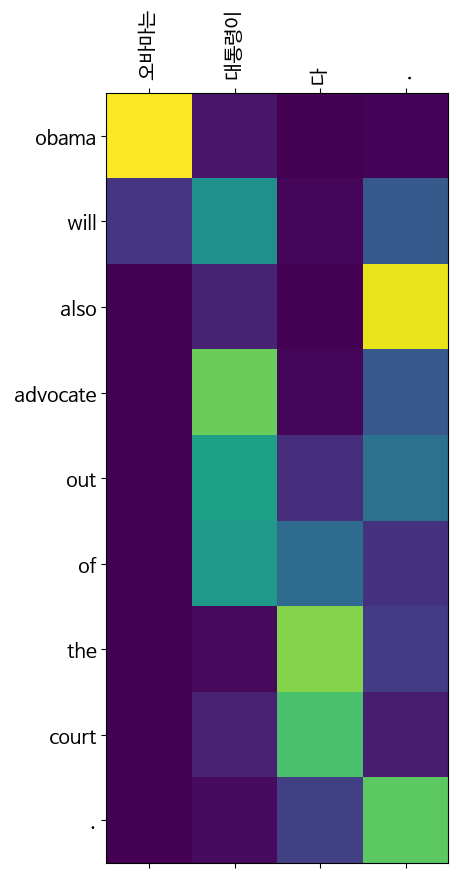

Input: 시민들은 도시 속에 산다 .
Predicted translation: the city s subway cities are to be lifted throughout .


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


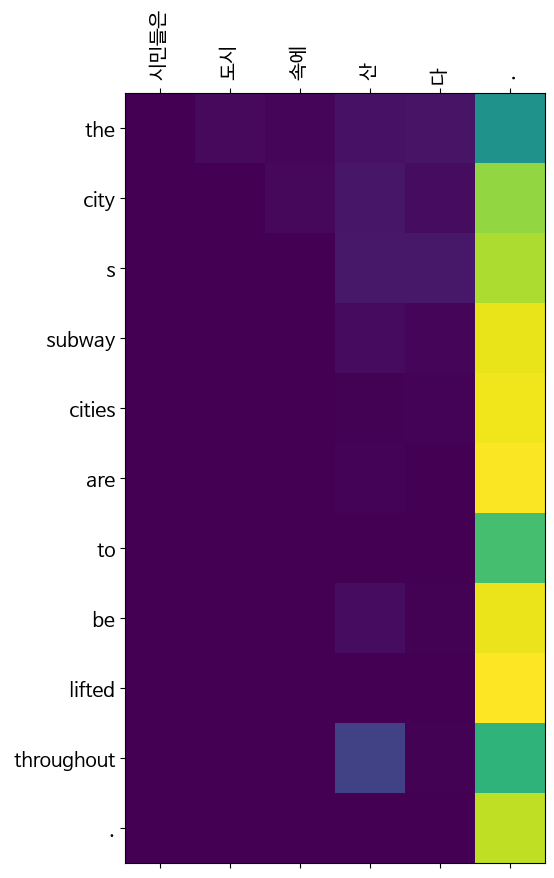

Input: 커피는 필요 없다 .
Predicted translation: need to need doesn t need to get one .


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


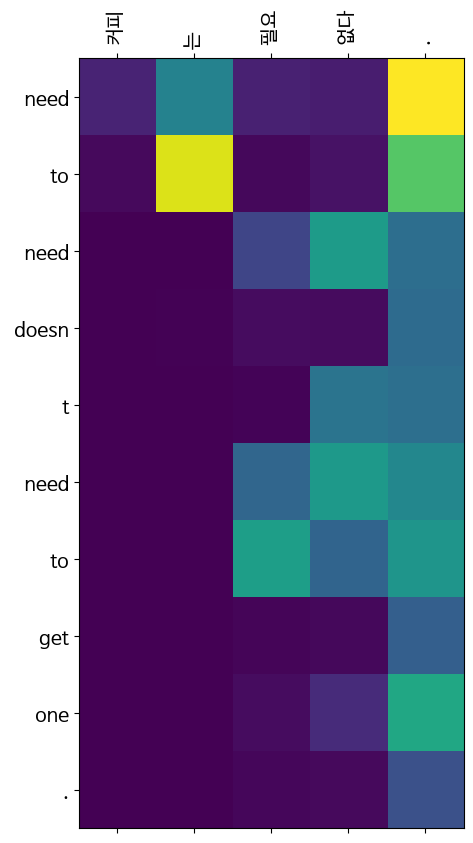

Input: 일곱 명의 사망자가 발생했다 .
Predicted translation: another person died .


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


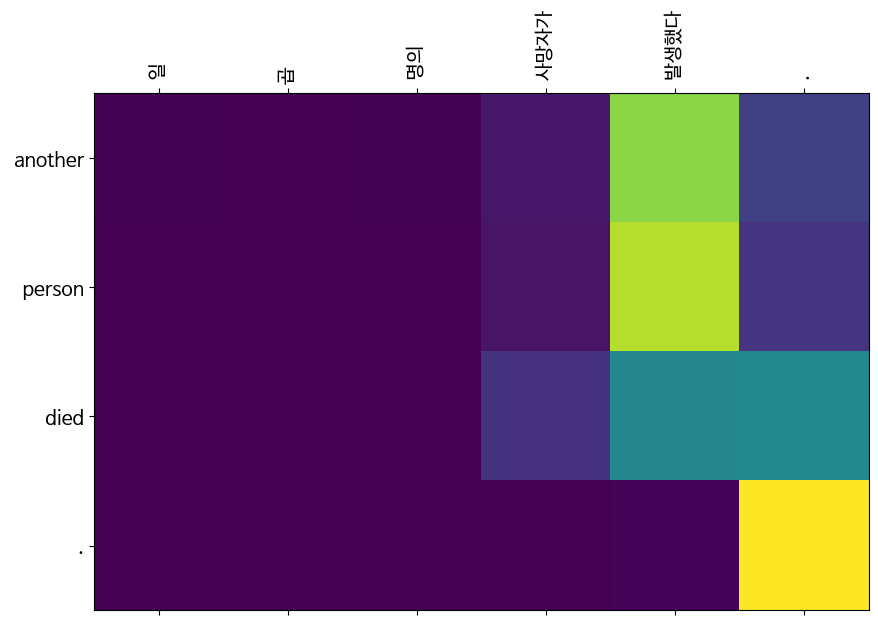

In [ ]:
for sent in example_sentences:
    translate(sent, model, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)


## 회고

loss는 1.5까지 낮췄으나, 아직 번역 퀄리티가 매우 아쉽다.
더 개선해보고 싶었지만, 모델을 돌리는 시간이 오래 걸려 하지 못했다.
좋은 GPU 등의 컴퓨팅 자원이 왜 가치가 높아지고 있는지 체감했다.
